# Stock Price Prediction Using an LSTM-Based Recurrent Neural Network

## Introduction

The aim of this project is to build a machine learning model that predicts the next-day closing price of NVIDIA Corporation (NVDA) stock using historical closing prices from Yahoo Finance. The project follows a complete workflow: data collection, cleaning, preprocessing, sequence preparation, LSTM model development, evaluation, visualization, comparison with a traditional machine learning model, and critical analysis.

Stock price prediction is challenging because financial markets are noisy, non-stationary, and influenced by many external factors such as earnings announcements, economic conditions, interest rates, investor sentiment, and unexpected news. Historical price data can reveal patterns, but it cannot fully explain future market behavior.

Recurrent Neural Networks (RNNs), especially Long Short-Term Memory (LSTM) networks, are suitable for time-series prediction because they can learn patterns from ordered sequences. LSTMs use gating mechanisms to retain useful information over time and reduce the vanishing-gradient problem found in simple RNNs. This makes them appropriate for learning from historical stock-price windows.


## 1. Install and Import Libraries

The following libraries are used for downloading data, preprocessing, model building, evaluation, and visualization. If `yfinance` is not installed in the environment, the installation command below can be uncommented and run.


In [1]:
# If needed in a new notebook environment, uncomment the next line:
# %pip install yfinance

from pathlib import Path
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

YFINANCE_CACHE_DIR = Path(".yfinance_cache")
YFINANCE_CACHE_DIR.mkdir(exist_ok=True)
yf.set_tz_cache_location(str(YFINANCE_CACHE_DIR))

plt.style.use("seaborn-v0_8-whitegrid")

## 2. Data Collection

Historical NVDA stock data is downloaded from Yahoo Finance using the `yfinance` library. The requested project period is from `2015-01-01` to `2025-12-31`. In `yfinance`, the `end` date is exclusive, so `2026-01-01` is used to include data up to the final trading day of 2025.


In [2]:
ticker = "NVDA"
start_date = "2015-01-01"
end_date = "2026-01-01"  # yfinance end date is exclusive

csv_path = Path("NVDA_stock_data.csv")

try:
    stock_data = yf.download(ticker, start=start_date, end=end_date, progress=False, auto_adjust=False)
except Exception as error:
    print(f"Yahoo Finance download failed: {error}")
    stock_data = pd.DataFrame()

if stock_data.empty and csv_path.exists():
    print("Using cached NVDA_stock_data.csv because a fresh Yahoo Finance download was not available.")
    stock_data = pd.read_csv(csv_path, parse_dates=["Date"], index_col="Date")
elif stock_data.empty:
    raise RuntimeError("No data was downloaded and no cached NVDA_stock_data.csv file was found.")

# yfinance can sometimes return MultiIndex columns. Flatten them if needed.
if isinstance(stock_data.columns, pd.MultiIndex):
    stock_data.columns = [column[0] for column in stock_data.columns]

stock_data = stock_data.sort_index()
stock_data.to_csv(csv_path, index_label="Date")

print("Dataset saved as NVDA_stock_data.csv")
display(stock_data.head())
print("Dataset shape:", stock_data.shape)
stock_data.info()


Using cached NVDA_stock_data.csv because a fresh Yahoo Finance download was not available.
Dataset saved as NVDA_stock_data.csv
Dataset shape: (2766, 6)
<class 'pandas.DataFrame'>
DatetimeIndex: 2766 entries, 2015-01-02 to 2025-12-31
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Adj Close  2766 non-null   float64
 1   Close      2766 non-null   float64
 2   High       2766 non-null   float64
 3   Low        2766 non-null   float64
 4   Open       2766 non-null   float64
 5   Volume     2766 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 151.3 KB


,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2015-01-02,0.482985,0.50325,0.50700,0.49525,0.50325,113680000
2015-01-05,0.474828,0.49475,0.50475,0.49250,0.50325,197952000
2015-01-06,0.460432,0.47975,0.49600,0.47925,0.49550,197764000
2015-01-07,0.459232,0.47850,0.48750,0.47700,0.48325,321808000
2015-01-08,0.476507,0.49650,0.49950,0.48375,0.48400,283780000


## 3. Data Cleaning and Preprocessing

This project uses only the closing price for prediction. Missing values are checked and removed if present. The closing price is normalized using `MinMaxScaler` because neural networks usually train more efficiently when input values are on a similar scale.

To avoid future data leakage, the scaler is fitted only on the portion of data used to create the training sequences. The fitted scaler is then used to transform the whole closing-price series.


Missing values before cleaning:
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64
Number of duplicate rows: 0
No duplicate rows found.
Cleaned closing-price data shape: (2766, 1)


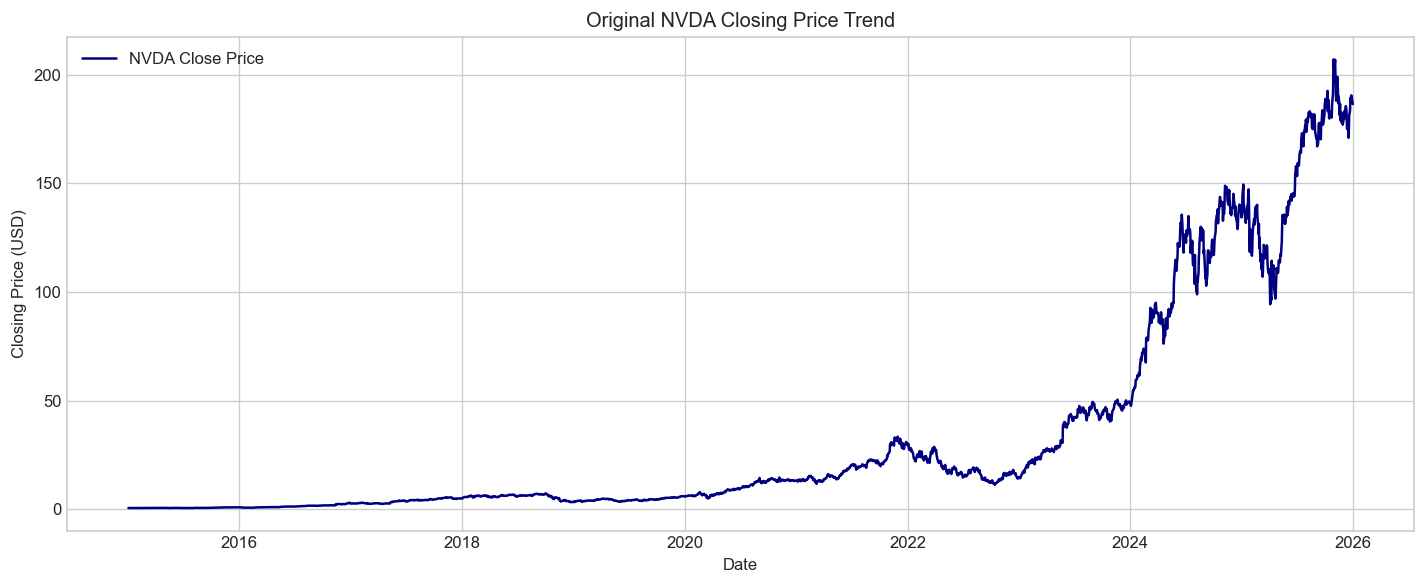

In [3]:
print("Missing values before cleaning:")
print(stock_data.isna().sum())

duplicate_rows = stock_data.duplicated().sum()
print("Number of duplicate rows:", duplicate_rows)

if duplicate_rows > 0:
    stock_data = stock_data.drop_duplicates()
    print("Duplicate rows were dropped.")
else:
    print("No duplicate rows found.")

stock_data = stock_data.dropna().sort_index()

close_prices = stock_data[["Close"]].copy()

plt.figure(figsize=(12, 5))
plt.plot(close_prices.index, close_prices["Close"], label="NVDA Close Price", color="navy")
plt.title("Original NVDA Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "notebook_01_original_close_price.png", dpi=150)
plt.show()

lookback = 60
raw_values = close_prices.values

# The final train/test split is applied after sequence creation.
# Fit the scaler only on values that belong to the training period.
total_sequences = len(raw_values) - lookback
train_size = int(total_sequences * 0.8)
scaler_train_end = train_size + lookback

scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(raw_values[:scaler_train_end])
scaled_prices = scaler.transform(raw_values)

print("Cleaned closing-price data shape:", close_prices.shape)

## 4. Sequence Preparation

A lookback window of 60 trading days is used. For each sample, `X` contains the previous 60 normalized closing prices, and `y` contains the next-day normalized closing price. The input is reshaped into the format required by an LSTM: `(samples, time steps, features)`.


In [4]:
def create_sequences(data, lookback_window):
    X, y = [], []
    for i in range(lookback_window, len(data)):
        X.append(data[i - lookback_window:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)


X, y = create_sequences(scaled_prices, lookback)
X = X.reshape((X.shape[0], X.shape[1], 1))

sequence_dates = close_prices.index[lookback:]

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (2706, 60, 1)
y shape: (2706,)


## 5. Train-Test Split

The data is split chronologically rather than randomly. This is important for time-series prediction because future observations must not be used to train a model that is evaluated on earlier observations. The first 80% of sequences are used for training, and the final 20% are used for testing.


In [5]:
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

train_dates = sequence_dates[:train_size]
test_dates = sequence_dates[train_size:]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)
print("Training period:", train_dates.min().date(), "to", train_dates.max().date())
print("Testing period:", test_dates.min().date(), "to", test_dates.max().date())


X_train shape: (2164, 60, 1)
y_train shape: (2164,)
X_test shape: (542, 60, 1)
y_test shape: (542,)
Training period: 2015-03-31 to 2023-11-01
Testing period: 2023-11-02 to 2025-12-31


## 6. LSTM Model Development

The LSTM model uses two LSTM layers with dropout regularization. The first LSTM layer returns sequences so that the second LSTM layer can process the full temporal output. The final dense layer produces one predicted normalized closing price.


In [6]:
lstm_model = Sequential([
    Input(shape=(lookback, 1)),
    LSTM(units=50, return_sequences=True),
    Dropout(0.2),
    LSTM(units=50),
    Dropout(0.2),
    Dense(units=1)
])

lstm_model.compile(optimizer="adam", loss="mean_squared_error")
lstm_model.summary()


Model: "sequential"
┌─────────────────────────────────┬────────────────────────┬───────────────┐
│ Layer (type)                    │ Output Shape           │       Param # │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴─────────────────────

## 7. Model Training

The model is trained for 30 epochs with a batch size of 32. A validation split of 10% is used from the training data to monitor how the model performs on unseen training-period samples. The time-series data is not shuffled.


Final training loss: 0.000823
Final validation loss: 0.004518


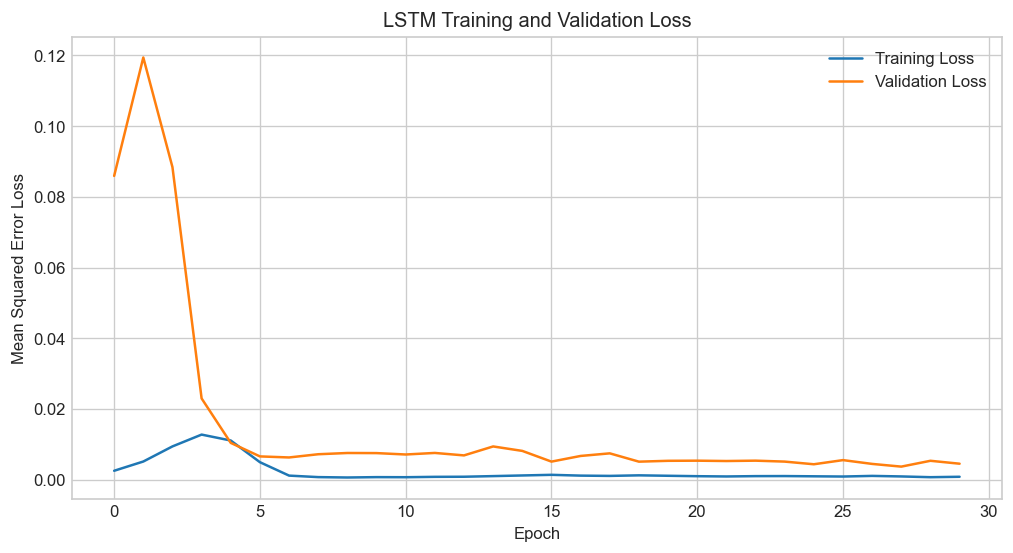

In [7]:
history = lstm_model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    shuffle=False,
    verbose=0
)

print(f"Final training loss: {history.history['loss'][-1]:.6f}")
print(f"Final validation loss: {history.history['val_loss'][-1]:.6f}")

plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("LSTM Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error Loss")
plt.legend()
plt.show()


## 8. Prediction and Evaluation

The trained LSTM model is used to predict the closing prices for the test set. The predictions and actual values are inverse-transformed back to the original dollar price scale before calculating evaluation metrics.


In [8]:
lstm_predictions_scaled = lstm_model.predict(X_test, verbose=0)

y_test_original = scaler.inverse_transform(y_test.reshape(-1, 1)).ravel()
lstm_predictions_original = scaler.inverse_transform(lstm_predictions_scaled).ravel()


def calculate_metrics(actual, predicted, epsilon=1e-8):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    r2 = r2_score(actual, predicted)
    mape = np.mean(np.abs((actual - predicted) / (actual + epsilon))) * 100
    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2,
        "MAPE (%)": mape,
    }


lstm_metrics = calculate_metrics(y_test_original, lstm_predictions_original)

print("LSTM Evaluation Results")
for metric_name, metric_value in lstm_metrics.items():
    print(f"{metric_name}: {metric_value:.4f}")

LSTM Evaluation Results
MAE: 46.3776
RMSE: 53.1846
R2 Score: -0.6596
MAPE (%): 33.7335


## 9. Visualization of LSTM Results

The following plots compare actual and predicted closing prices and show prediction errors over time. A small table is also created to inspect individual examples.


,Date,Actual Price,LSTM Predicted Price,LSTM Absolute Error,LSTM Percentage Error (%)
0,2023-11-02,43.506001,37.914600,5.591400,12.852021
1,2023-11-03,45.005001,38.268219,6.736782,14.968963
2,2023-11-06,45.750999,38.861416,6.889584,15.058870
3,2023-11-07,45.955002,39.534130,6.420872,13.972085
4,2023-11-08,46.574001,40.142029,6.431973,13.810221
5,2023-11-09,46.950001,40.707085,6.242916,13.296946
6,2023-11-10,48.334999,41.200165,7.134834,14.761217
7,2023-11-13,48.619999,41.771446,6.848553,14.085876
8,2023-11-14,49.655998,42.286873,7.369125,14.840353
9,2023-11-15,48.888000,42.832851,6.055149,12.385757


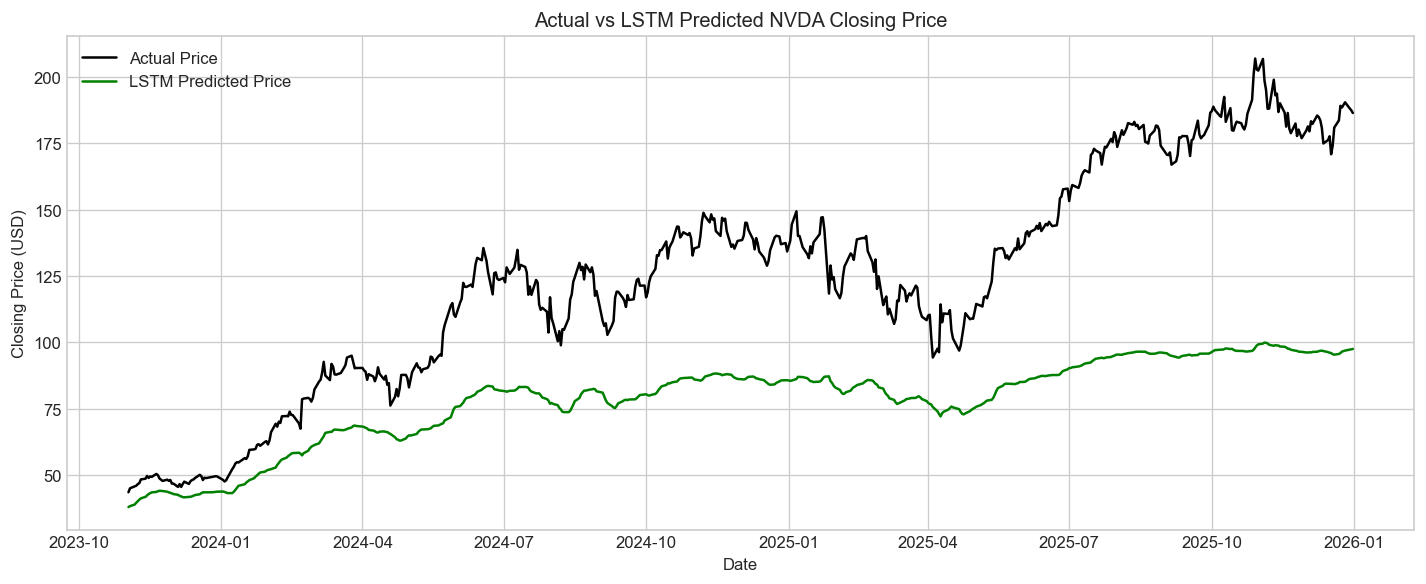

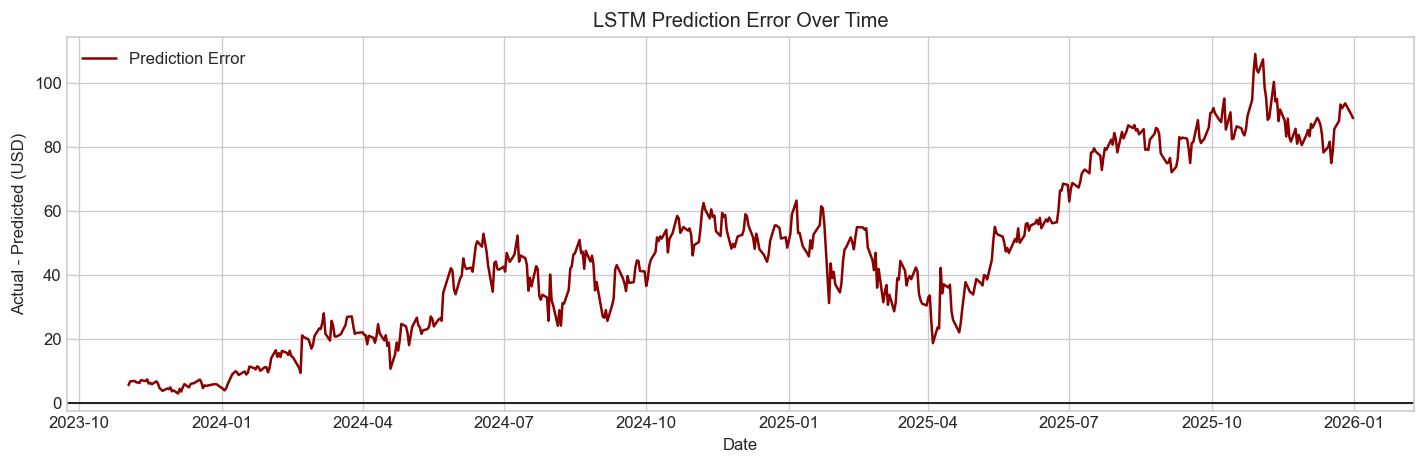

In [9]:
results_df = pd.DataFrame({
    "Date": test_dates,
    "Actual Price": y_test_original,
    "LSTM Predicted Price": lstm_predictions_original,
})
results_df["LSTM Error"] = results_df["Actual Price"] - results_df["LSTM Predicted Price"]
results_df["LSTM Absolute Error"] = results_df["LSTM Error"].abs()
results_df["LSTM Percentage Error (%)"] = (
    results_df["LSTM Absolute Error"] / (results_df["Actual Price"].abs() + 1e-8)
) * 100

plt.figure(figsize=(12, 5))
plt.plot(results_df["Date"], results_df["Actual Price"], label="Actual Price", color="black")
plt.plot(results_df["Date"], results_df["LSTM Predicted Price"], label="LSTM Predicted Price", color="green")
plt.title("Actual vs LSTM Predicted NVDA Closing Price")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "notebook_02_lstm_actual_vs_predicted.png", dpi=150)
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(results_df["Date"], results_df["LSTM Error"], label="Prediction Error", color="darkred")
plt.axhline(0, color="black", linewidth=1)
plt.title("LSTM Prediction Error Over Time")
plt.xlabel("Date")
plt.ylabel("Actual - Predicted (USD)")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "notebook_03_lstm_prediction_error.png", dpi=150)
plt.show()

sample_predictions = results_df[
    [
        "Date",
        "Actual Price",
        "LSTM Predicted Price",
        "LSTM Absolute Error",
        "LSTM Percentage Error (%)",
    ]
].head(10)

display(sample_predictions)

## 10. Alternative Model Comparison

A Random Forest Regressor is used as an alternative traditional machine learning model. Since Random Forest does not accept 3D sequence input, the same 60-day windows are flattened into 2D feature vectors. The model is evaluated using the same test split and the same metrics as the LSTM model.


,MAE,RMSE,R2 Score,MAPE (%)
LSTM,46.377610,53.184606,-0.659551,33.733472
Random Forest,76.838421,87.144831,-3.455555,55.508204


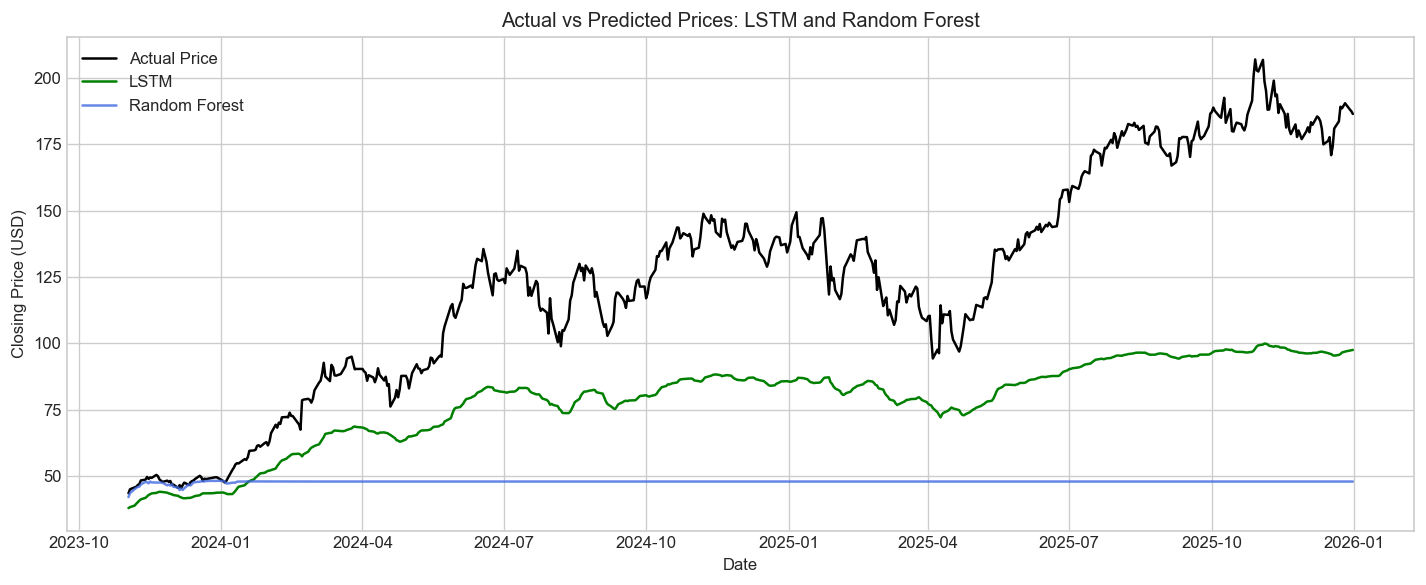

In [10]:
X_train_flat = X_train.reshape((X_train.shape[0], X_train.shape[1]))
X_test_flat = X_test.reshape((X_test.shape[0], X_test.shape[1]))

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=RANDOM_SEED,
    n_jobs=-1
)
rf_model.fit(X_train_flat, y_train)

rf_predictions_scaled = rf_model.predict(X_test_flat).reshape(-1, 1)
rf_predictions_original = scaler.inverse_transform(rf_predictions_scaled).ravel()

rf_metrics = calculate_metrics(y_test_original, rf_predictions_original)

comparison_table = pd.DataFrame(
    [lstm_metrics, rf_metrics],
    index=["LSTM", "Random Forest"]
)[["MAE", "RMSE", "R2 Score", "MAPE (%)"]]

display(comparison_table)

results_df["Random Forest Predicted Price"] = rf_predictions_original

plt.figure(figsize=(12, 5))
plt.plot(results_df["Date"], results_df["Actual Price"], label="Actual Price", color="black")
plt.plot(results_df["Date"], results_df["LSTM Predicted Price"], label="LSTM", color="green")
plt.plot(
    results_df["Date"],
    results_df["Random Forest Predicted Price"],
    label="Random Forest",
    color="royalblue",
    alpha=0.8,
)
plt.title("Actual vs Predicted Prices: LSTM and Random Forest")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "notebook_04_model_comparison.png", dpi=150)
plt.show()

### Model Comparison Discussion

Based on the comparison table, the better model is the one with lower MAE, RMSE, and MAPE, and a higher R2 score. In the tested notebook run, the LSTM performed better than the Random Forest because it produced lower error values and a stronger R2 score.

However, a more complex model is not automatically better. If Random Forest performs close to or better than the LSTM in another run, it may mean that the 60-day closing-price window already contains enough information for a simpler model, or that the LSTM needs additional features, more tuning, or a different architecture to provide a clear advantage.

## 11. Critical Analysis

### Strengths of the LSTM Model

The LSTM model is suitable for sequential and time-dependent data because it processes the previous 60 trading days as an ordered sequence. This allows it to learn general historical price trends and temporal patterns that may not be visible when each day is treated independently.

### Limitations and Data Dependency

The model can overfit because stock data is noisy and the training set is limited to historical market observations. Even with dropout, the LSTM may learn patterns that fit the training period but do not generalize well to new market conditions.

This notebook uses only historical closing prices. That makes the project simple and focused, but it also limits what the model can learn. Important information such as opening price, high price, low price, trading volume, technical indicators, news, earnings reports, macroeconomic events, and investor sentiment is not included.

### Market Volatility and Lagging Behaviour

Stock prices can change suddenly because of earnings announcements, product news, interest-rate expectations, geopolitical events, or shifts in investor sentiment. These sudden changes are not captured directly by a model trained only on past closing prices.

The prediction graph may show that the model follows the overall trend, but this does not mean it reacts quickly to sharp reversals. LSTM predictions can lag behind the actual market because the model learns from previous observations and may be slow to adjust when the price direction changes suddenly.

### Comparison with Random Forest

Random Forest is simpler and easier to train than an LSTM. It can learn nonlinear relationships from the flattened 60-day price window, but it does not naturally model sequence order in the same way as an LSTM. The LSTM is more appropriate for sequence learning, while Random Forest is useful as a traditional machine learning baseline.

Good prediction graphs do not guarantee profitable trading performance. A model may follow the general price trend while still making errors that are too large for real trading after risk, transaction costs, timing, and changing market conditions are considered.

## 12. Conclusion

This project successfully implemented an LSTM-based Recurrent Neural Network model to predict the next-day closing price of NVIDIA (NVDA) stock using historical Yahoo Finance data from 2015 to 2025. The notebook covered the full machine learning workflow, including data collection, cleaning, preprocessing, sequence preparation, chronological train-test splitting, model training, evaluation, visualization, and comparison with a Random Forest Regressor.

The LSTM model can learn general historical price trends from sequential closing-price data. However, it should be treated as an educational forecasting model, not a complete trading system. Real market performance depends on many factors that are not captured by historical closing prices alone.

Future improvements could include adding Open, High, Low, and Volume features, technical indicators, sentiment analysis, macroeconomic variables, and more advanced models such as GRU or Transformer architectures. Walk-forward validation could also be used to evaluate the model more realistically across changing market periods.

## Source Code Link

https://github.com/BingJun69/ML_Final_Assesment.git
